In [37]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import src.config as config
import re
import cv2
import src.data_preprocessing.image_data_exploration as data_exploration

# Prepare LeafLet for Merging

In [2]:
#Read in the Data from PlantVQA and LeafLet datasets
Leaf_obj = config.Data.LeafBranch

#Read in the CSV files for LeafLet
file_name_store = []
for file in Leaf_obj.CSV.iterdir():
    file_name_store.append(file)

leaf_let_df = pd.read_csv(file_name_store[0])

for file in file_name_store[1:]:
    df_temp = pd.read_csv(file)
    leaf_let_df = pd.concat([leaf_let_df, df_temp], axis=0, ignore_index=True)





In [3]:
leaf_let_df[leaf_let_df['question_type'] == 'SNC'].head()

,image,question_id,question_type,question,A,B,C,D,answer
7740,test-00003-of-00006_765.png,snc::1,SNC,What is the scientific name of the plant show...,Botryosphaeria spp.,Microdochium oryzae,Mononychellus tanajoa,Leucoptera coffeella,A
7741,test-00003-of-00006_766.png,snc::2,SNC,What is the scientific name of the plant show...,Sugarcane yellow leaf virus,Cercospora coffeicola,Capnodium spp.,Botryosphaeria spp.,D
7742,test-00003-of-00006_767.png,snc::3,SNC,What is the scientific name of the plant show...,Tomato yellow leaf curl virus (TYLCV),Botryosphaeria spp.,Hemileia vastatrix,Xanthomonas campestris pv. mangiferaeindicae,B
7743,test-00003-of-00006_768.png,snc::4,SNC,What is the scientific name of the plant show...,Cassava mosaic geminivirus,Phaeomoniella chlamydospora,Botryosphaeria spp.,Procontarinia matteiana,C
7744,test-00003-of-00006_769.png,snc::5,SNC,What is the scientific name of the plant show...,"between 2,7 and 7",Botryosphaeria spp.,Sporisorium scitamineum,Calepitrimerus vitis,B


In [4]:

#Create a Map of Multiple choice answer to Text Answer
leaf_let_df['text_answer'] = None
for index, row in leaf_let_df.iterrows():
    if row['answer'] == 'A':
        leaf_let_df.at[index, 'text_answer'] = row['A']
    elif row['answer'] == 'B':
        leaf_let_df.at[index, 'text_answer'] = row['B']
    elif row['answer'] == 'C':
        leaf_let_df.at[index, 'text_answer'] = row['C']
    elif row['answer'] == 'D':
        leaf_let_df.at[index, 'text_answer'] = row['D']



In [5]:

#After changing the answer column to text, we can drop the multiple choice columns
leaf_let_df = leaf_let_df.drop(columns=['A', 'B', 'C', 'D'])

In [6]:
leaf_let_df = leaf_let_df.drop(columns=['question_id'])

In [7]:
leaf_let_df[leaf_let_df['question_type'] == 'CSI'].head()

,image,question_type,question,answer,text_answer
5160,test-00002-of-00006_510.png,CSI,Which plant species is visible in this image?,D,Apple
5161,test-00002-of-00006_511.png,CSI,Which plant species is visible in this image?,A,Apple
5162,test-00002-of-00006_512.png,CSI,Which plant species is visible in this image?,A,Apple
5163,test-00002-of-00006_513.png,CSI,Which plant species is visible in this image?,A,Apple
5164,test-00002-of-00006_514.png,CSI,Which plant species is visible in this image?,D,Apple


In [8]:
#Add the crop column to the LeafLet dataset
leaf_let_df['crop'] = pd.NA
leaf_let_df['disease'] = pd.NA
for index, row in leaf_let_df.iterrows():
    if row['question_type'] == 'CSI':
        leaf_let_df.at[index, 'crop'] = row['text_answer']

crop_df = leaf_let_df.copy()

In [9]:
crop_df = crop_df.dropna(subset=['crop'])

In [10]:
crops = crop_df['crop'].dropna().astype(str).unique()
crops = [crop.strip() for crop in crops if crop.strip() != '']
crops = [re.escape(crop) for crop in crops]
pattern = r'^(' + '|'.join(crops) + r')\b\s*(.*)$'

In [11]:
print(pattern)

^(Apple|Cashew|Cassava|Cherry|Coffee|Maize|Cucumber|Grape|Mango|Orange|Peach|Pepper|Black\ Pepper|Potato|Raspberry|Rice|Soybean|Squash|Strawberry|Sugarcane|Tea|Tomato)\b\s*(.*)$


In [12]:
disease_df = leaf_let_df[leaf_let_df['crop'].isna()].copy()
for index, row in disease_df.iterrows():
    if row['question_type'] =='DC':
        crop = re.search(pattern, row['text_answer'], re.IGNORECASE)
        if crop:
            disease_df.at[index, 'crop'] = crop.group(1)
            disease_df.at[index, 'disease'] = crop.group(2)


In [13]:
disease_df = disease_df.dropna(subset=['crop'])

leaf_let_df = pd.concat([disease_df, crop_df], axis=0, ignore_index=True)

In [14]:
leaf_let_df = leaf_let_df.dropna(subset=['crop'])


In [15]:
crops = leaf_let_df['crop'].unique()
print(crops)

['Apple' 'Cashew' 'Cassava' 'Cherry' 'Coffee' 'Maize' 'Cucumber' 'Grape'
 'Mango' 'Orange' 'Peach' 'Pepper' 'Black Pepper' 'Potato' 'Raspberry'
 'Rice' 'Soybean' 'Squash' 'Strawberry' 'Sugarcane' 'Tea' 'Tomato']


In [16]:
print(leaf_let_df['disease'].unique())

['Black rot' 'Healthy' 'Anthracnose' 'Leaf miner' 'Rust'
 'Bacterial blight' 'Brown spot' 'Green mite' 'Mosaic' 'Powdery mildew'
 'Cerscospora' 'Miner' 'Maize Lethal Necrosis' 'Maize Streak Virus'
 'Cercospora leaf spot Gray leaf spot' 'Northern Leaf Blight'
 'Bacterial Wilt' 'Downy Mildew' 'Gummy Stem Blight' 'Brown Spot' 'Mites'
 'Esca (Black Measles)' 'Leaf blight (Isariopsis Leaf Spot)'
 'Bacterial Canker' 'Cutting Weevil' 'Die Back' 'Gall Midge'
 'Powdery Mildew' 'Sooty Mould' 'Haunglongbing (Citrus greening)'
 'Bacterial spot' 'leaf spot' 'yellow mottle virus' 'Early blight'
 'Late blight' 'Scald' 'Smut' 'Narrow Brown Spot' 'scorch'
 'Banded Chlorosis' 'Brown Rust' 'Dried Leaves' 'Grassy shoot'
 'Pokkah Boeng' 'Sett Rot' 'mosaic virus' 'Yellow Leaf' 'Leaf blight'
 'Red leaf spot' 'Red scab' 'Leaf Mold' 'Septoria leaf spot'
 'Spider mites Two-spotted spider mite' 'Target Spot'
 'Yellow Leaf Curl Virus' <NA>]


In [17]:
print(leaf_let_df['crop'].value_counts())

crop
Tomato          600
Sugarcane       600
Mango           480
Grape           420
Maize           360
Cassava         300
Rice            300
Tea             240
Cashew          240
Coffee          240
Cucumber        240
Pepper          180
Potato          180
Apple           120
Cherry          120
Strawberry      120
Peach           120
Orange           60
Black Pepper     60
Squash           60
Raspberry        60
Soybean          60
Name: count, dtype: int64


In [18]:

leaf_let_df['Dataset'] = 'LeafLet'
leaf_let_df['category'] = None
leaf_let_df = leaf_let_df.drop(columns=['question_type', 'question', 'answer', 'text_answer'])


#rearrange columns for clear structure
leaf_let_df = leaf_let_df[['image', 'crop', 'disease', 'category', 'Dataset']]

leaf_let_df = leaf_let_df.rename(columns={'image': 'image_path'})
for index, row in leaf_let_df.iterrows():
    leaf_let_df.at[index, 'image_path'] = str(Leaf_obj.IMAGES / row['image_path'])

In [19]:
print(leaf_let_df.columns)


Index(['image_path', 'crop', 'disease', 'category', 'Dataset'], dtype='object')


### Prepare VQA for merging

In [20]:
#Perform the same for PlantVQA dataset
PlantVQA_obj = config.Data.PlantExpertVQA

vqa_df = pd.read_csv(PlantVQA_obj.TRAIN_FILE)
temp_test = pd.read_csv(PlantVQA_obj.TEST_FILE)
temp_val = pd.read_csv(PlantVQA_obj.VALIDATION_FILE)

vqa_df = pd.concat([vqa_df, temp_test, temp_val], axis=0)

C:\Users\Kyler_Code\AppData\Local\Temp\ipykernel_16864\1771744492.py:4: DtypeWarning: Columns (9) have mixed types. Specify dtype option on import or set low_memory=False.
  vqa_df = pd.read_csv(PlantVQA_obj.TRAIN_FILE)


In [21]:
print(vqa_df.question_category.value_counts())

question_category
Specific Disease Identification    199001
Causal Reasoning                   110884
Plant Species Identification       108447
Comprehensive Description           89264
Detailed Verification               85646
General Health Assessment           66572
Counterfactual Reasoning            61781
Visual Attribute Grounding          36232
Existence & Sanity Check             2845
Name: count, dtype: int64


In [22]:
print(vqa_df.columns)

Index(['qa_id', 'image_id', 'image_path', 'crop', 'disease', 'category',
       'severity', 'question_text', 'answer', 'answer_type',
       'question_category', 'cognitive_level', 'dataset_source'],
      dtype='object')


In [23]:
#drop the columns we do not need for the image model
vqa_df = vqa_df.drop(columns=['qa_id','question_text', 'answer', 'answer_type', 'question_category', 'cognitive_level', 'dataset_source', 'severity'])

In [24]:
#Filter and remove Disease cateories that relate to sensescence
vqa_df = vqa_df[~vqa_df['category'].isin(['senescence', 'natural_senescence'])]

vqa_df = vqa_df.drop_duplicates(subset=['image_id'])
vqa_df = vqa_df.drop(columns=['image_id'])
print(vqa_df.category.value_counts())

category
disease    115445
healthy     32002
Name: count, dtype: int64


In [25]:
print(vqa_df.columns)
vqa_df['Dataset'] = 'PlantVQA'

Index(['image_path', 'crop', 'disease', 'category'], dtype='object')


#### Prepare GBIF/USDA for merging

In [26]:
#Read in the GBIF/USDA data
gbif_obj = config.Data.GBIF
gbif_df = pd.read_csv(gbif_obj.FULL_FILE)

In [27]:
print(gbif_df.columns)

Index(['image_id', 'image_path', 'group', 'family', 'genus', 'crop', 'disease',
       'category', 'severity'],
      dtype='object')


In [28]:
gbif_df = gbif_df.drop(columns=['image_id', 'group', 'family', 'genus', 'severity'])

gbif_df['Dataset'] = 'GBIF/USDA'

In [29]:
gbif_df.columns

Index(['image_path', 'crop', 'disease', 'category', 'Dataset'], dtype='object')

In [30]:
for name, d in [('leaf', leaf_let_df), ('vqa', vqa_df), ('gbif', gbif_df)]:
    print(name, d.columns)

leaf Index(['image_path', 'crop', 'disease', 'category', 'Dataset'], dtype='object')
vqa Index(['image_path', 'crop', 'disease', 'category', 'Dataset'], dtype='object')
gbif Index(['image_path', 'crop', 'disease', 'category', 'Dataset'], dtype='object')


In [31]:
#Concatenate All datasets

final_df = pd.concat([leaf_let_df, vqa_df, gbif_df], axis=0, ignore_index=True)

In [32]:
print(final_df['Dataset'].value_counts())

Dataset
GBIF/USDA    148251
PlantVQA     147447
LeafLet        5160
Name: count, dtype: int64


In [33]:
final_df = final_df[final_df['crop'] != 'unknown']


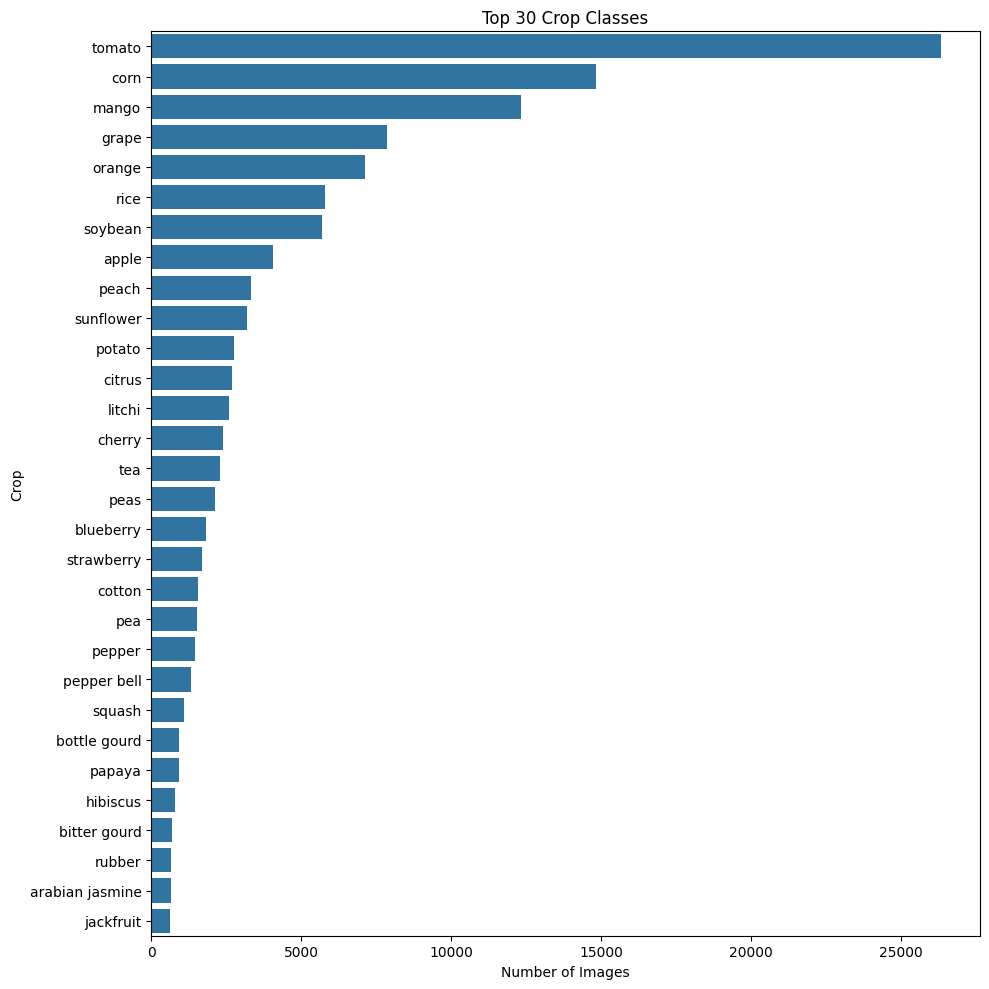

In [34]:
counts = final_df['crop'].value_counts().head(30)

plt.figure(figsize=(10,10))
sns.barplot(x=counts.values, y=counts.index, orient='h')
plt.title(f'Top 30 Crop Classes')
plt.xlabel('Number of Images')
plt.ylabel('Crop')
plt.tight_layout()
plt.show()

In [40]:
#image variance exploration after resizing
GBIF_PATH = config.Data.GBIF.IMAGES
gbif_laplacian_variances = []
for item in GBIF_PATH.iterdir():
    if len(list(item.iterdir())) < 20:
        continue
    random_images = np.random.choice(list(item.iterdir()), size=20, replace=False)
    for image in random_images:
        img = cv2.imread(str(image))
        
        laplacian_var = data_exploration.get_variance_of_laplacian(img)
        gbif_laplacian_variances.append((laplacian_var.item(), item.name, img.shape[0], img.shape[1], img.shape[2]))

gbif_var_df = pd.DataFrame(gbif_laplacian_variances, columns=["Laplacian_Variance", "Class", "Height", "Width", "Shape"])

gbif_var_df.to_csv("gbif_laplacian_variance.csv", index=False)

KeyboardInterrupt: 

Text(0, 0.5, 'Frequency')

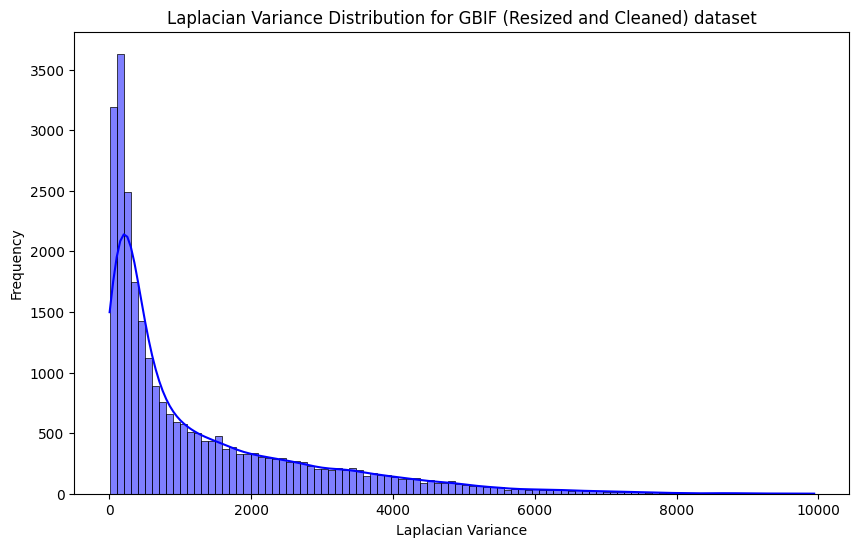

In [43]:
#Explore the GBIF laplacian variance distribution

gbif_var_df = pd.read_csv("gbif_laplacian_variance.csv")
gbif_var_df = gbif_var_df[gbif_var_df["Laplacian_Variance"] < 10000]
gbif_var_df.describe()

#get the count of each unique image size and shape for the GBIF dataset
#image_size_counts = gbif_var_df.groupby(["Width", "Height"]).size()
#print(image_size_counts[image_size_counts == image_size_counts.max()])

#Generate a histogram of the laplacian variance distribution for the GBIF dataset
plt.figure(figsize=(10, 6))
sns.histplot(data=gbif_var_df, x="Laplacian_Variance", bins=100, kde=True, color="blue")
plt.title("Laplacian Variance Distribution for GBIF (Resized and Cleaned) dataset")
plt.xlabel("Laplacian Variance")
plt.ylabel("Frequency")


In [48]:
#Resize LeafLet images and PlantVQA images
import src.data_preprocessing.image_preprocessing as ip
LeafLet_image_path = config.Data.LeafBranch.IMAGES
SAVE_PATH = config.Data.LeafBranch.ROOT / 'resized_images'
for jpg in LeafLet_image_path.iterdir():
        save_path = SAVE_PATH / jpg.name
        try:
            img = ip.preprocess_image(jpg)
            ip.save_image(img, save_path=save_path)
        except cv2.error as e:
             print(f"Error Converting image {save_path}: {e}")
        except Exception as e:
            print(f"Error Converting image {save_path}: {e}")


In [49]:

LeafLet_laplacian_variances = []
random_images = np.random.choice(list(SAVE_PATH.iterdir()), size=7000, replace=False)
for image in random_images: 

    img = cv2.imread(str(image))
    laplacian_var = data_exploration.get_variance_of_laplacian(img)
    LeafLet_laplacian_variances.append((laplacian_var.item(), item.name, img.shape[0], img.shape[1], img.shape[2]))

LeafLet_var_df = pd.DataFrame(LeafLet_laplacian_variances, columns=["Laplacian_Variance", "Class", "Height", "Width", "Shape"])

LeafLet_var_df.to_csv("LeafLet_laplacian_variance_resized.csv", index=False)

Text(0, 0.5, 'Frequency')

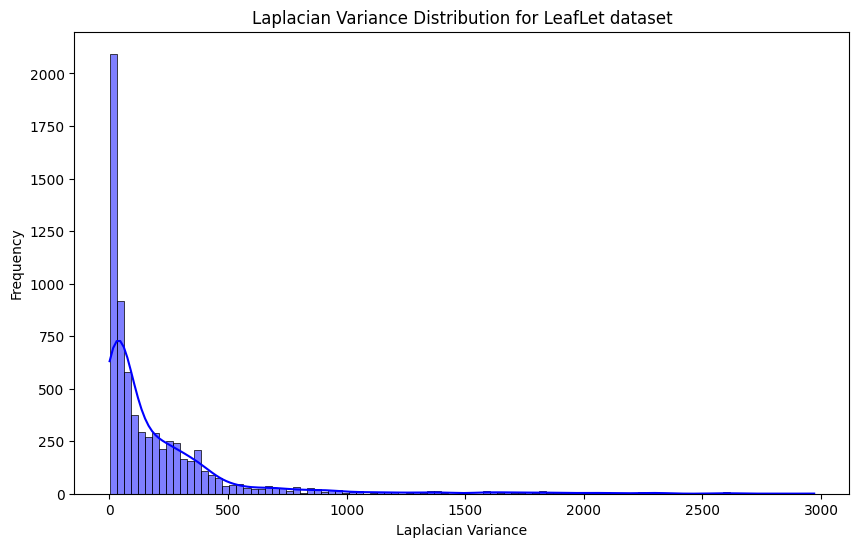

In [50]:
leaflet_var_df = pd.read_csv("LeafLet_laplacian_variance_resized.csv")
leaflet_var_df.describe()

leaflet_var_df = leaflet_var_df[leaflet_var_df["Laplacian_Variance"] < 10000]

plt.figure(figsize=(10, 6))
sns.histplot(data=leaflet_var_df, x="Laplacian_Variance", bins=100, kde=True, color="blue")
plt.title("Laplacian Variance Distribution for LeafLet dataset")
plt.xlabel("Laplacian Variance")
plt.ylabel("Frequency")